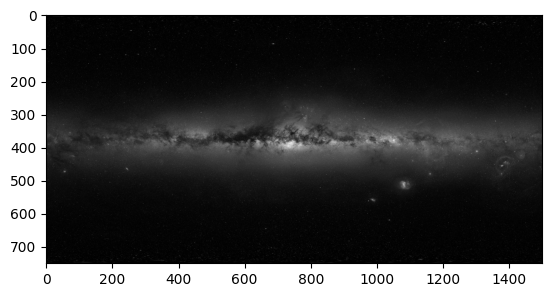

In [1]:
import matplotlib.pyplot as plt

img = plt.imread('AllSkySurvey_Risinger1500.jpg')

gray = img.mean(axis=2, keepdims=False)

plt.imshow(gray, cmap='gray')

In [2]:
H, W = gray.shape

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y

# -----------------------------
# 1. Define the grid
# -----------------------------
N, M = W, H  # polar and azimuthal points
theta = np.linspace(0, np.pi, M)  # azimuthal angle
phi = np.linspace(0, 2*np.pi, N, endpoint=False)                      # polar angle (colatitude)

Theta, Phi = np.meshgrid(theta, phi)  # shape (N, M)

# -----------------------------
# 2. Define scalar field f(theta, phi)
# -----------------------------
# Example: sum of spherical harmonics with noise
f = sph_harm_y(2, -1, Theta, Phi) 
f = gray.T
# -----------------------------
# 3. Compute spherical harmonic coefficients using orthonormality
# -----------------------------
L_max = 100  # maximum degree
c_nm = np.zeros((L_max+1, 2*L_max+1), dtype=complex)  # store m=-L..L as offset

# Quadrature weights for polar angle (sin(phi) * dphi)
dphi = phi[1] - phi[0]
dtheta = theta[1] - theta[0]

for n in range(L_max+1):
    print(n)
    for m in range(-n, n+1):
        Y_nm = sph_harm_y(n, m, Theta, Phi)          # shape (N, M)
        integrand = f * np.conj(Y_nm)              # elementwise multiplication
        c_nm[n, m+L_max] = np.sum(np.sin(Theta) * integrand) * dtheta * dphi

# -----------------------------
# 4. Reconstruct the field from coefficients
# -----------------------------
f_reconstructed = np.zeros_like(f, dtype=complex)
for n in range(L_max+1):
    for m in range(-n, n+1):
        f_reconstructed += (c_nm[n, m+L_max] * sph_harm_y(n, m, Theta, Phi))

f_reconstructed = f_reconstructed.real

# -----------------------------
# 5. Plot original vs reconstructed field
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original scalar field (with noise)")
plt.pcolormesh(Phi, Theta, f, shading='auto', cmap='viridis')
plt.xlabel('Theta (azimuth)')
plt.ylabel('Phi (polar)')
plt.colorbar(label='f')

plt.subplot(1,2,2)
plt.title(f"Reconstructed field (L_max = {L_max})")
plt.pcolormesh(Phi, Theta, f_reconstructed, shading='auto', cmap='viridis')
plt.xlabel('Theta (azimuth)')
plt.ylabel('Phi (polar)')
plt.colorbar(label='f_reconstructed')

plt.tight_layout()
plt.show()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [ ]:
np.save(f'milkyway_sph_harm_reconstruction_{L_max}.npy', c_nm)

[[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  -9.36285142e-20+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -5.92980590e-19-3.31600988e-19j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  -1.37321821e-18+2.42848959e-19j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.